<a href="https://colab.research.google.com/github/saivivekreddydevaram/ML-MINI-PROJECTS/blob/main/SalaryPrediction/SalaryPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [15]:
url = 'https://raw.githubusercontent.com/saivivekreddydevaram/ML-MINI-PROJECTS/refs/heads/main/SalaryPrediction/job_salary_prediction_dataset.csv'
salary_data = pd.read_csv(url)
m = len(salary_data)

In [16]:
salary_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


MAPPING CATEGORICAL DATA AS NUMBERS

In [17]:
education_map  = {
    'High School' : 0,
    'Diploma' : 1,
    'Bachelor' : 2,
    'Master' : 3,
    'PhD' : 4
}
salary_data['education_level_num'] = salary_data['education_level'].map(education_map)

In [18]:
industry_map = {'Healthcare' : 0,
                'Telecom' : 1,
                'Media' : 2,
                'Retail' : 3,
                'Manufacturing' : 4,
                'Education' : 5,
                'Finance' : 6,
                'Technology' : 7,
                'Consulting' : 8,
                'Government' : 9}
salary_data['industry_num'] = salary_data['industry'].map(industry_map)

In [19]:
company_size_map = {'Medium' : 1,
                    'Small' : 2,
                    'Large' : 3,
                    'Enterprise' : 4,
                    'Startup' : 5}
salary_data['company_size_num'] = salary_data['company_size'].map(company_size_map)

In [20]:
job_title_map = {'AI Engineer' : 1,
                 'Data Analyst':2,
                 'Frontend Developer':3,
                 'Business Analyst':4,
                 'Product Manager':5,
                 'Backend Developer':6,
                 'Machine Learning Engineer':7,
                 'DevOps Engineer':8,
                 'Software Engineer' :9,
                 'Cybersecurity Analyst' : 10,
                 'Data Scientist':11,
                 'Cloud Engineer':12
                 }
salary_data['job_title_num'] = salary_data['job_title'].map(job_title_map)


In [21]:
country_map = {
    'India': 0,
    'Australia': 1,
    'Singapore': 2,
    'Canada': 3,
    'Sweden': 4,
    'USA': 5,
    'Netherlands': 6,
    'Remote': 7,
    'Germany': 8,
    'UK': 9
}
salary_data['country_num'] = salary_data['location'].map(country_map)

In [22]:
remote_work_map = {
    'Hybrid' : 0,
    'No' : 1,
    'Yes' : 2
}
salary_data['remote_work_num'] = salary_data['remote_work'].map(remote_work_map)

In [23]:
x_features =  salary_data[['job_title_num', 'education_level_num','skills_count',
       'industry_num', 'company_size_num', 'country_num', 'remote_work_num', 'certifications']].values
x_ones = np.ones((m,1))
X = np.hstack((x_ones,x_features))
Y = salary_data['salary'].values
theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(Y)

In [24]:
theta

array([9.03165119e+04, 7.58351928e+02, 8.08162879e+03, 8.68182346e+02,
       7.79604951e+00, 6.87898129e+02, 3.73746313e+03, 2.71589887e+03,
       1.61667102e+03])

In [25]:
predictions = X.dot(theta)
errors = np.abs(Y - predictions)
print(f"Average Prediction Error (MAE): ${errors.mean():.2f}")

Average Prediction Error (MAE): $26590.98


PLOT OF REPRESANTING THE PREDICTED AND ACTUAL SALARIES

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


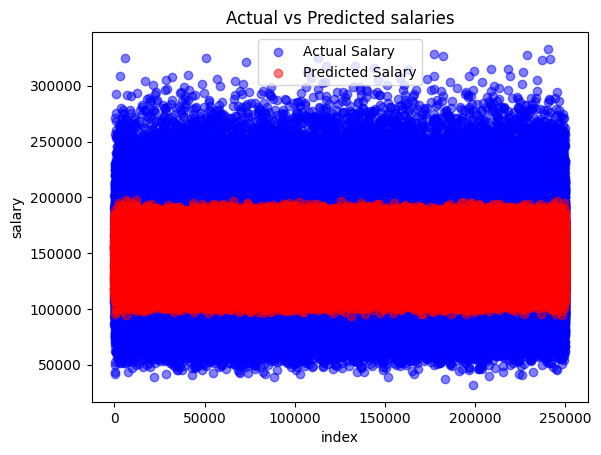

In [28]:
plt.scatter(range(len(Y)), Y, color='blue', alpha=0.5, label='Actual Salary')
plt.scatter(range(len(predictions)), predictions, color='red', alpha=0.5, label='Predicted Salary')
plt.xlabel("index")
plt.ylabel("salary")
plt.title("Actual vs Predicted salaries")
plt.legend()
plt.show()


In [27]:
salary_data['salary'].mean()

np.float64(145718.080524)